# Draft-model mistake analysis

Analyzes **which tokens the EAGLE3 draft gets wrong** on eval benchmarks, to decide *what training corpus would help*.

Input is the `mistakes.jsonl` from `score_mistakes.py` (run on the GPU box). This notebook needs no GPU. Three lenses:

1. **Token categories** — what *kind* of token the draft misses (code punctuation, numbers, LaTeX/math, identifiers, prose …), contrasting benchmarks.
2. **Rare-in-training cross-reference** — missed tokens that were rare/absent in the training data (`token_freq.pt`). This is the direct corpus signal.
3. **Position & TTT-depth** — where in the sequence / at which draft depth it fails.

In [1]:
# --- config: edit these paths ---
MISTAKES_JSONL = "out/redhat_mistakes.jsonl"                    # from score_mistakes.py
VERIFIER       = "/sms-scratch/checkpoints/gemma-4-31B-it"    # for token decoding
TOKEN_FREQ_PT  = "/sms-scratch/ravira/datasets/kimi-mtp-nemotron-stem-code/token_freq.pt"

import matplotlib.pyplot as plt
import pandas as pd
import mistake_lib as ML
pd.set_option("display.max_rows", 60)

In [2]:
# --- load + enrich ---
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained(VERIFIER, trust_remote_code=True)
freq = ML.load_token_freq(TOKEN_FREQ_PT)

df = ML.load_mistakes(MISTAKES_JSONL)
df = ML.attach_token_strings(df, tok)
df = ML.add_categories(df)
df = ML.add_training_freq(df, freq)
print(len(df), "token records across", df.benchmark.nunique(), "benchmarks")
df.head()

/home/ravira/miniconda3/envs/speculators/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


263826 token records across 3 benchmarks


,benchmark,id,ttt_step,aligned_pos,seq_len,rel_pos,pred_id,target_id,correct,cond_correct,target_str,pred_str,category,train_freq,freq_bucket
0,gpqa_diamond,0,0,154,527,0.292220,6054,6054,True,True,determine,determine,natural_word,90746,common (>=10k)
1,gpqa_diamond,0,0,155,527,0.294118,837,837,True,True,which,which,natural_word,328520,common (>=10k)
2,gpqa_diamond,0,0,156,527,0.296015,815,13401,False,False,planet,has,natural_word,9826,medium
3,gpqa_diamond,0,0,157,527,0.297913,815,815,True,True,has,has,natural_word,232858,common (>=10k)
4,gpqa_diamond,0,0,158,527,0.299810,506,506,True,True,the,the,natural_word,12720458,common (>=10k)


## Headline acceptance
`step0_accept` is the base accept rate (dominates end-to-end acceptance length).

In [3]:
ML.summary(df)

,benchmark,n_tokens,step0_accept,mean_cond_accept
0,aime,27104,0.669532,0.530217
1,gpqa_diamond,33599,0.619989,0.440698
2,livecodebench,27239,0.643452,0.441658


## Lens 1 — token categories
Where do step-0 mistakes concentrate, and how does accuracy per category differ across benchmarks? High `mistake_share` = that category is where errors pile up.

In [4]:
cat = ML.token_category_breakdown(df, ttt_step=0)
cat

,benchmark,category,n,accuracy,mistakes,mistake_share
2,aime,latex_math,6325,0.592569,2577,0.287708
3,aime,natural_word,9641,0.741624,2491,0.278107
0,aime,code_punct,4008,0.556387,1778,0.198504
5,aime,number,5085,0.680236,1626,0.181534
1,aime,indent_ws,1210,0.682645,384,0.042871
4,aime,newline,791,0.927939,57,0.006364
6,aime,other,44,0.000000,44,0.004912
10,gpqa_diamond,natural_word,14537,0.643599,5181,0.405780
9,gpqa_diamond,latex_math,6502,0.554906,2894,0.226660
7,gpqa_diamond,code_punct,4909,0.559584,2162,0.169330


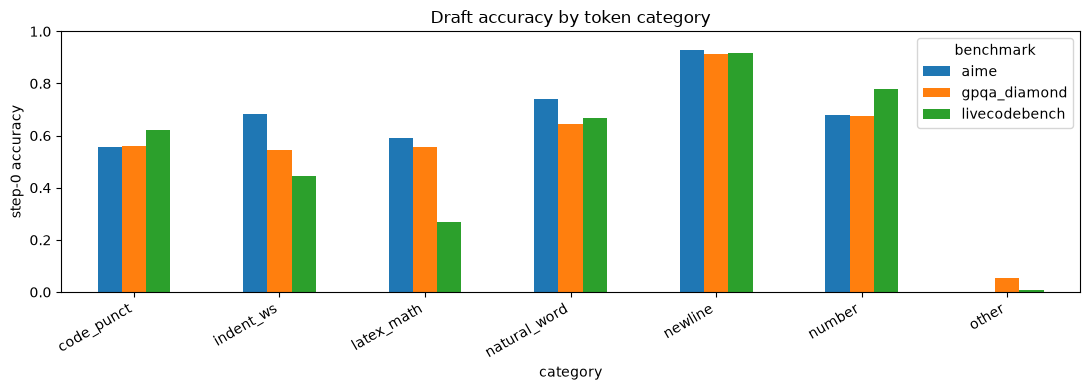

In [5]:
piv = cat.pivot(index="category", columns="benchmark", values="accuracy")
ax = piv.plot(kind="bar", figsize=(11,4))
ax.set_ylabel("step-0 accuracy"); ax.set_title("Draft accuracy by token category")
ax.set_ylim(0,1); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

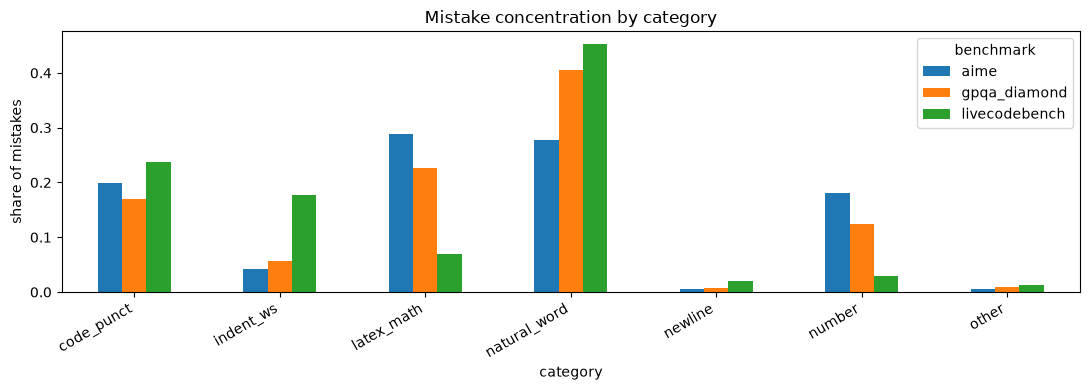

In [6]:
piv2 = cat.pivot(index="category", columns="benchmark", values="mistake_share").fillna(0)
ax = piv2.plot(kind="bar", figsize=(11,4))
ax.set_ylabel("share of mistakes"); ax.set_title("Mistake concentration by category")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## Lens 2 — rare-in-training cross-reference
**The corpus signal.** If accuracy collapses on `absent`/`rare` tokens, the draft is failing on content it barely saw in training — add a corpus rich in those.

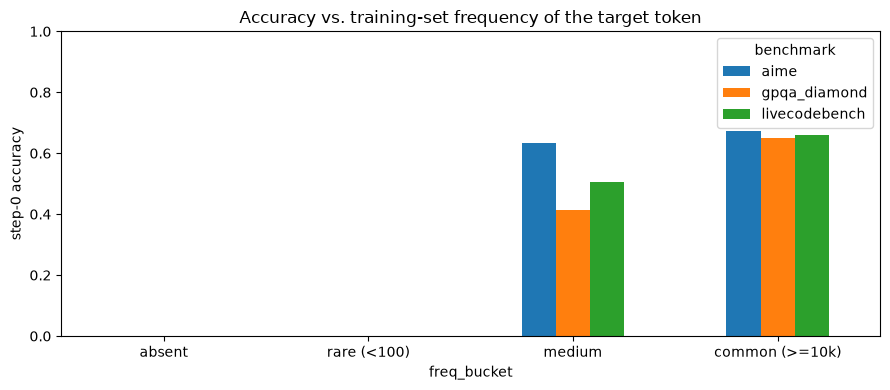

,benchmark,freq_bucket,n,accuracy
0,aime,absent,14,0.000000
3,aime,rare (<100),52,0.000000
2,aime,medium,1476,0.634146
1,aime,common (>=10k),25562,0.673304
4,gpqa_diamond,absent,42,0.000000
7,gpqa_diamond,rare (<100),198,0.000000
6,gpqa_diamond,medium,3681,0.412931
5,gpqa_diamond,common (>=10k),29678,0.650684
8,livecodebench,absent,47,0.000000
11,livecodebench,rare (<100),81,0.000000


In [7]:
fb = ML.accuracy_by_freq_bucket(df, ttt_step=0)
piv = fb.pivot(index="freq_bucket", columns="benchmark", values="accuracy")
ax = piv.plot(kind="bar", figsize=(9,4))
ax.set_ylabel("step-0 accuracy"); ax.set_ylim(0,1)
ax.set_title("Accuracy vs. training-set frequency of the target token")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
fb

### Shortlist: frequently-missed AND rare-in-training tokens
These are the concrete tokens to go find more training data for.

In [8]:
ML.top_missed_rare_tokens(df, ttt_step=0, max_train_freq=10000, top_n=40)

,target_id,target_str,mistakes,train_freq,benchmarks
0,0,<pad>,129,2,"aime,gpqa_diamond,livecodebench"
1,106,<turn|>,102,0,"aime,gpqa_diamond,livecodebench"
4,147,,37,2647,livecodebench
674,21724,methyl,31,3232,gpqa_diamond
789,27536,nums,28,2132,livecodebench
1764,245337,⊕,22,8,livecodebench
1377,88947,GeV,22,304,gpqa_diamond
373,10922,pc,22,640,gpqa_diamond
820,28751,typing,21,3965,livecodebench
249,7518,anya,21,413,livecodebench


## Lens 3 — TTT depth & position

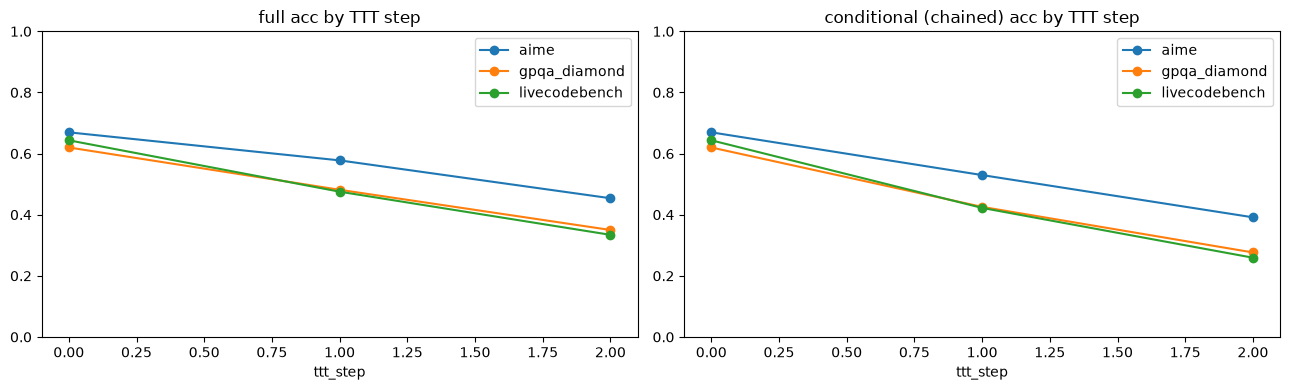

,benchmark,ttt_step,n,full_acc,cond_acc
0,aime,0,27104,0.669532,0.669532
1,aime,1,27104,0.577738,0.529664
2,aime,2,27104,0.453881,0.391455
3,gpqa_diamond,0,33599,0.619989,0.619989
4,gpqa_diamond,1,33599,0.481562,0.425608
5,gpqa_diamond,2,33599,0.350040,0.276496
6,livecodebench,0,27239,0.643452,0.643452
7,livecodebench,1,27239,0.475311,0.422262
8,livecodebench,2,27239,0.334117,0.259261


In [9]:
dp = ML.depth_profile(df)
fig, ax = plt.subplots(1,2, figsize=(13,4))
for b, g in dp.groupby("benchmark"):
    ax[0].plot(g.ttt_step, g.full_acc, marker="o", label=b)
    ax[1].plot(g.ttt_step, g.cond_acc, marker="o", label=b)
ax[0].set_title("full acc by TTT step"); ax[1].set_title("conditional (chained) acc by TTT step")
for a in ax: a.set_xlabel("ttt_step"); a.set_ylim(0,1); a.legend()
plt.tight_layout(); plt.show()
dp

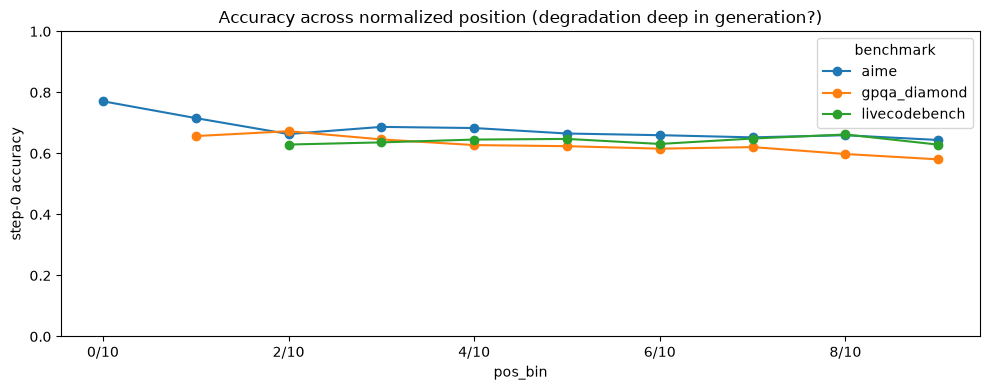

In [10]:
pp = ML.position_profile(df, ttt_step=0, bins=10)
piv = pp.pivot(index="pos_bin", columns="benchmark", values="accuracy")
ax = piv.plot(marker="o", figsize=(10,4))
ax.set_ylabel("step-0 accuracy"); ax.set_ylim(0,1)
ax.set_title("Accuracy across normalized position (degradation deep in generation?)")
plt.tight_layout(); plt.show()

---
### Reading this for corpus selection
- **Lens 2** is the money shot: a big accuracy gap between `common` and `absent`/`rare` on gpqa/livecodebench means those benchmarks lean on tokens under-represented in `kimi-mtp`. The shortlist names them.
- **Lens 1** tells you the *theme* (code punctuation vs. LaTeX vs. prose) so you can pick a corpus (more code, more math/science) rather than chase individual tokens.
- **Lens 3** separates "draft is weak everywhere" (low step-0) from "draft decays with depth/length" (fine at step-0, collapses deeper) — different fixes.